# Qwen3.5-4B Fine-Tuning On FineTree (A100)

This notebook fine-tunes `Qwen/Qwen3.5-4B` using Unsloth on `asafd60/FineTree-annotated-pages`.

It mirrors the style of Unsloth's professional Qwen notebook flow:
- install + environment checks
- model + LoRA setup
- dataset prep
- training
- optional save/push
- manual evaluation


## Runtime

Recommended runtime:
- GPU: A100 40GB/80GB
- Python: 3.10+
- Internet access for HF model/dataset download

Dataset split behavior in this notebook:
- Loads the public dataset from Hugging Face
- Concatenates any existing splits
- Re-splits locally to `train/validation = 90/10`


In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0

In [2]:
%%capture
! pip uninstall unsloth unsloth_zoo -y
! pip install git+https://github.com/unslothai/unsloth-zoo.git --no-deps
! pip install git+https://github.com/unslothai/unsloth.git --no-deps

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
BF16 supported: True


## Load Model (Vision-first, text fallback)

The notebook prefers multimodal training if the model/runtime supports `FastVisionModel`.
If not available, it falls back to `FastLanguageModel` and trains only on instruction/output text.


In [1]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 4096
lora_rank = 16

model, processor = FastLanguageModel.from_pretrained(
    "unsloth/Qwen3.5-4B", # This is a very big model, might take a while for downloading
    max_seq_length = max_seq_length,
    load_in_4bit = False,
    fast_inference = False, # Not supported for MoE (yet!)
)
tokenizer = processor.tokenizer # To tokenize text

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.2.1: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [2]:
import random
from pathlib import Path

import torch

SEED = 3407
MODEL_ID = "unsloth/Qwen3.5-4B"
DATASET_ID = "asafd60/FineTree-annotated-pages"
VAL_RATIO = 0.1

MAX_SEQ_LENGTH = 4096
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0

PER_DEVICE_BATCH_SIZE = 8
GRAD_ACC_STEPS = 1
LEARNING_RATE = 2e-4
NUM_TRAIN_EPOCHS = 10
WARMUP_RATIO = 0.03
LOGGING_STEPS = 1
EVAL_STEPS = 1
SAVE_STEPS = 1

OUTPUT_DIR = "artifacts/qwen35-4b-finetree"
PUSH_ADAPTER_TO_HUB = False
HF_ADAPTER_REPO_ID = ""

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("BF16 supported:", torch.cuda.is_bf16_supported())

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
BF16 supported: True


In [3]:
from unsloth import FastLanguageModel

use_vision_path = True
try:
    from unsloth import FastVisionModel, UnslothVisionDataCollator
except Exception:
    use_vision_path = False

if use_vision_path:
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name=MODEL_ID,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else None,
        load_in_4bit=True,
        trust_remote_code=True,
    )
    model = FastVisionModel.get_peft_model(
        model,
        r=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        use_rslora=False,
        use_gradient_checkpointing="unsloth",
        random_state=SEED,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
        ],
        finetune_vision_layers=True,
        finetune_language_layers=True,
        finetune_attention_modules=True,
        finetune_mlp_modules=True,
    )
    print("Using multimodal path (FastVisionModel).")
else:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_ID,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else None,
        load_in_4bit=True,
        trust_remote_code=True,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        use_gradient_checkpointing=True,
        random_state=SEED,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
        ],
    )
    print("Using text fallback path (FastLanguageModel).")


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.2.1: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Qwen3_5 does not support SDPA - switching to fast eager.


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Unsloth: Making `model.base_model.model.model.language_model` require gradients
Using multimodal path (FastVisionModel).


In [4]:
from datasets import DatasetDict, concatenate_datasets, load_dataset

raw = load_dataset(DATASET_ID)
if isinstance(raw, DatasetDict):
    all_splits = [raw[name] for name in raw.keys()]
    full_ds = concatenate_datasets(all_splits) if len(all_splits) > 1 else all_splits[0]
else:
    full_ds = raw

required_cols = {"image", "instruction", "output"}
missing = required_cols - set(full_ds.column_names)
if missing:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing)}")

full_ds = full_ds.shuffle(seed=SEED)
split = full_ds.train_test_split(test_size=VAL_RATIO, seed=SEED)
train_ds = split["train"]
val_ds = split["test"]

print("Total rows:", len(full_ds))
print("Train rows:", len(train_ds))
print("Validation rows:", len(val_ds))

Total rows: 45
Train rows: 40
Validation rows: 5


## Build Training Samples

Multimodal path:
- user = image + instruction
- assistant = output

Text fallback path:
- user = instruction
- assistant = output


In [5]:
def build_messages(example):
    if use_vision_path:
        return {
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": example["image"]},
                        {"type": "text", "text": example["instruction"]},
                    ],
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": example["output"]}],
                },
            ]
        }
    return {
        "conversations": [
            {"role": "user", "content": example["instruction"]},
            {"role": "assistant", "content": example["output"]},
        ]
    }

train_prepared = train_ds.map(build_messages)
val_prepared = val_ds.map(build_messages)

if not use_vision_path:
    def formatting_prompts_func(examples):
        convos = examples["conversations"]
        texts = [
            tokenizer.apply_chat_template(
                convo,
                tokenize=False,
                add_generation_prompt=False,
            )
            for convo in convos
        ]
        return {"text": texts}

    train_prepared = train_prepared.map(formatting_prompts_func, batched=True)
    val_prepared = val_prepared.map(formatting_prompts_func, batched=True)

print("Prepared train rows:", len(train_prepared))
print("Prepared val rows:", len(val_prepared))


Prepared train rows: 40
Prepared val rows: 5


In [6]:

from trl import SFTConfig, SFTTrainer

if use_vision_path:
    # Compatibility helper across Unsloth versions.
    def build_vision_collator(collator_cls, model, tokenizer):
        import inspect

        try:
            params = inspect.signature(collator_cls).parameters
        except Exception:
            params = {}

        kwargs = {}
        if "model" in params:
            kwargs["model"] = model
        if "tokenizer" in params:
            kwargs["tokenizer"] = tokenizer
        elif "processor" in params:
            kwargs["processor"] = tokenizer

        if kwargs:
            return collator_cls(**kwargs)

        for fallback_kwargs in (
            {"model": model, "tokenizer": tokenizer},
            {"model": model},
            {"processor": tokenizer},
            {"tokenizer": tokenizer},
            {},
        ):
            try:
                return collator_cls(**fallback_kwargs)
            except TypeError:
                continue
        raise RuntimeError("Failed to initialize UnslothVisionDataCollator.")

    data_collator = build_vision_collator(UnslothVisionDataCollator, model, tokenizer)
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        data_collator=data_collator,
        train_dataset=train_prepared,
        eval_dataset=val_prepared,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        args=SFTConfig(
            output_dir=OUTPUT_DIR,
            seed=SEED,
            per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
            gradient_accumulation_steps=GRAD_ACC_STEPS,
            learning_rate=LEARNING_RATE,
            num_train_epochs=NUM_TRAIN_EPOCHS,
            warmup_ratio=WARMUP_RATIO,
            weight_decay=0.01,
            lr_scheduler_type="cosine",
            optim="adamw_8bit",
            logging_steps=LOGGING_STEPS,
            eval_strategy="steps",
            eval_steps=EVAL_STEPS,
            save_strategy="steps",
            save_steps=SAVE_STEPS,
            save_total_limit=2,
            bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
            fp16=False,
            report_to="none",
            remove_unused_columns=False,
        ),
    )
else:
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_prepared,
        eval_dataset=val_prepared,
        args=SFTConfig(
            output_dir=OUTPUT_DIR,
            seed=SEED,
            dataset_text_field="text",
            per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
            gradient_accumulation_steps=GRAD_ACC_STEPS,
            learning_rate=LEARNING_RATE,
            num_train_epochs=NUM_TRAIN_EPOCHS,
            warmup_ratio=WARMUP_RATIO,
            weight_decay=0.01,
            lr_scheduler_type="cosine",
            optim="adamw_8bit",
            logging_steps=LOGGING_STEPS,
            eval_strategy="steps",
            eval_steps=EVAL_STEPS,
            save_strategy="steps",
            save_steps=SAVE_STEPS,
            save_total_limit=2,
            bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
            fp16=False,
            report_to="none",
            remove_unused_columns=False,
        ),
    )

print("Trainer ready.")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Model does not have a default image size - using 512
Trainer ready.


In [7]:
if not use_vision_path:
    from unsloth.chat_templates import train_on_responses_only

    trainer = train_on_responses_only(
        trainer,
        instruction_part="<|im_start|>user",
        response_part="<|im_start|>assistant",
    )
    print("Applied response-only loss masking.")
else:
    print("Response-only masking skipped in multimodal path.")


Response-only masking skipped in multimodal path.


In [8]:
# Start training
if use_vision_path:
    FastVisionModel.for_training(model)
else:
    FastLanguageModel.for_training(model)

train_result = trainer.train()
print(train_result)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 40 | Num Epochs = 10 | Total steps = 50
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 1 x 1) = 8
 "-____-"     Trainable parameters = 21,233,664 of 4,560,499,200 (0.47% trained)


Step,Training Loss,Validation Loss
1,2.048373,1.748804
2,1.671014,1.346198
3,1.198779,1.061439
4,0.926082,0.974635
5,0.823321,0.897882
6,0.755050,0.818849
7,0.731687,0.736261
8,0.784402,0.649136
9,0.665464,0.558272
10,0.395621,0.475199


KeyboardInterrupt: 

In [ ]:
adapter_dir = Path(OUTPUT_DIR) / "adapter"
adapter_dir.mkdir(parents=True, exist_ok=True)

model.save_pretrained(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))
print("Saved adapter:", adapter_dir)

In [ ]:
# Optional adapter push
if PUSH_ADAPTER_TO_HUB:
    if not HF_ADAPTER_REPO_ID:
        raise ValueError("Set HF_ADAPTER_REPO_ID before enabling push.")
    model.push_to_hub(HF_ADAPTER_REPO_ID)
    tokenizer.push_to_hub(HF_ADAPTER_REPO_ID)
    print("Pushed:", HF_ADAPTER_REPO_ID)
else:
    print("Skipping push (PUSH_ADAPTER_TO_HUB=False).")

## Manual Evaluation (Random Validation Sample)

This section displays a random image and prints:
- instruction
- model output
- ground truth output

BBox matching is intentionally not enforced here (manual qualitative check only).


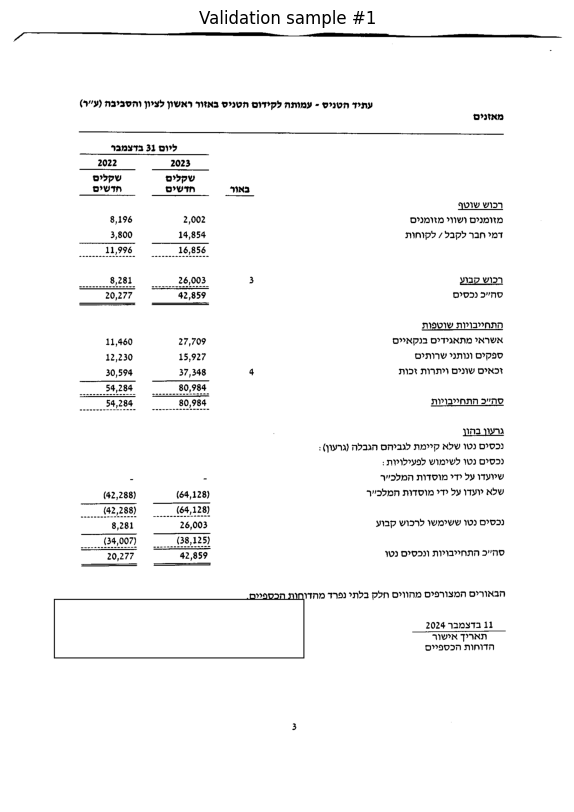

=== Instruction ===
You are extracting financial-statement annotations from a single page image into a strict JSON schema.

Return ONLY valid JSON (no markdown, no comments, no explanations).

Schema (must match exactly, including key spelling):
{
  "meta": {
    "entity_name": "<string|null>",
    "page_num": "<string|null>",
    "type": "balance_sheet|income_statement|cash_flow|notes|contents_page|title|declaration|profits|other",
    "title": "<string|null>"
  },
  "facts": [
    {
      "bbox": { "x": <number>, "y": <number>, "w": <number>, "h": <number> },
      "value": "<string>",
      "note": "<string|null>",
      "is_beur": "<boolean|null>",
      "beur_num": "<string|null>",
      "refference": "<string>",
      "date": "<string|null>",
      "path": ["<string>", "..."],
      "currency": "ILS|USD|EUR|GBP|null",
      "scale": 1|1000|1000000|null,
      "value_type": "amount|%|null"
    }
  ]
}

Extraction rules:
1. Extract ALL numeric facts visible in the table (including 

KeyboardInterrupt: 

In [13]:
import matplotlib.pyplot as plt
from transformers import TextStreamer

from transformers import TextStreamer
streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

sample_idx = random.randrange(len(val_ds))
sample = val_ds[sample_idx]

img = sample["image"]
plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.axis("off")
plt.title(f"Validation sample #{sample_idx}")
plt.show()

print("=== Instruction ===")
print(sample["instruction"])

if use_vision_path:
    FastVisionModel.for_inference(model)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": sample["instruction"]},
            ],
        }
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(
        images=[img],
        text=text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=2048,
        temperature=0.0,
        do_sample=False,
        streamer=streamer
    )
    prediction = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
else:
    FastLanguageModel.for_inference(model)
    messages = [{"role": "user", "content": sample["instruction"]}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=2048,
        temperature=0.0,
        do_sample=False,
    )
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("=== Model Output ===")
print(prediction)

print("=== Ground Truth Output ===")
print(sample["output"])
